In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
sales = pd.read_csv("../data/processed/sales_clean.csv")

sku = pd.read_csv("../data/processed/sku_clean.csv")

inventory = pd.read_csv("../data/processed/inventory_clean.csv")

print("Cleaned datasets loaded successfully!")

Cleaned datasets loaded successfully!


In [3]:
print(sales.columns.tolist())
print(sku.columns.tolist())
print(inventory.columns.tolist())

['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id']
['sku_id', 'sku_name', 'category', 'subcategory', 'unit_price', 'cost_price', 'brand']
['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']


In [4]:
sales["date"] = pd.to_datetime(sales["date"])
inventory["last_restock_date"] = pd.to_datetime(inventory["last_restock_date"])

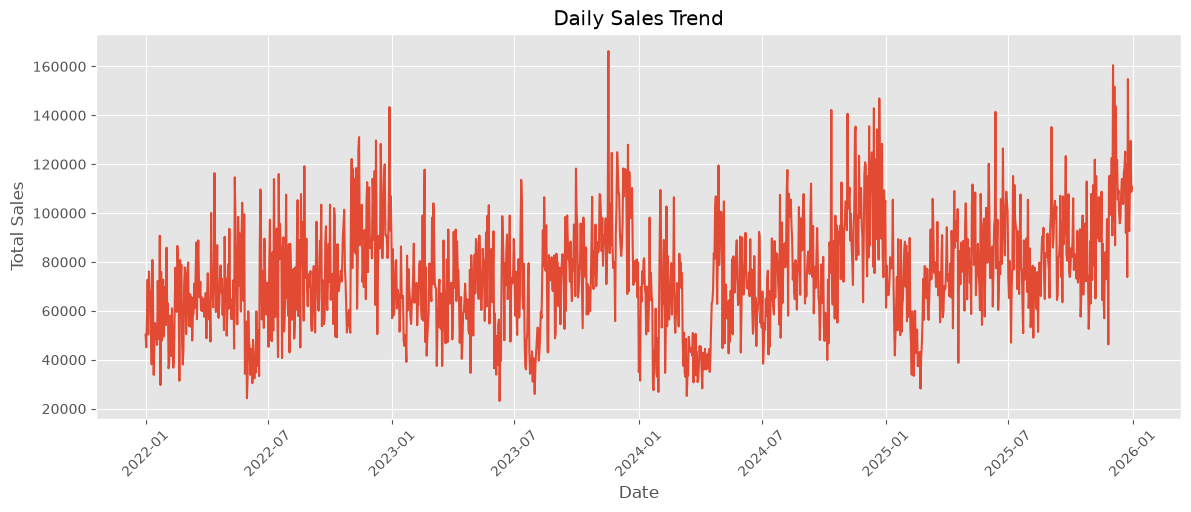

In [5]:
daily_sales = sales.groupby("date")["total_value"].sum()

plt.figure(figsize=(14,5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

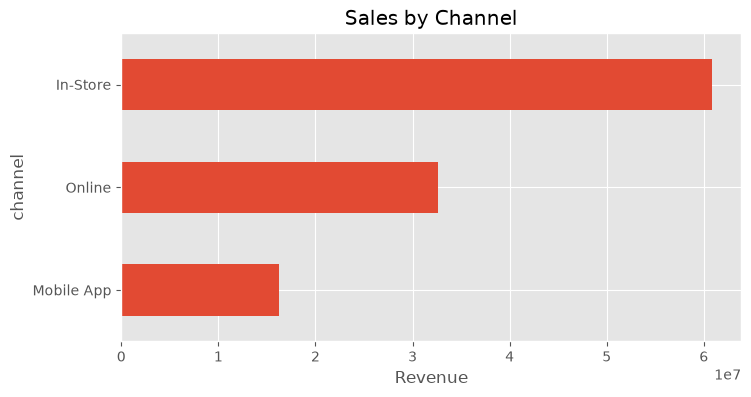

In [6]:
sales.groupby("channel")["total_value"].sum().sort_values().plot(
    kind="barh", figsize=(8,4)
)

plt.title("Sales by Channel")
plt.xlabel("Revenue")
plt.show()

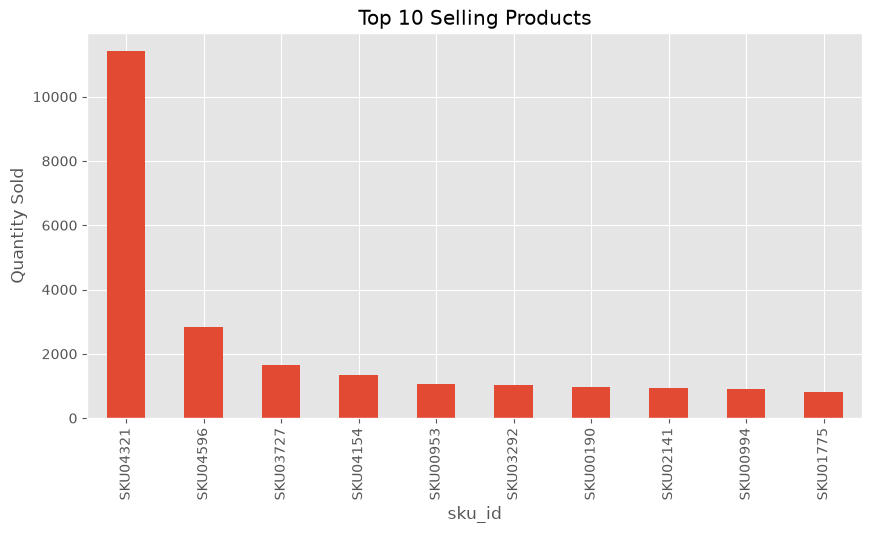

In [7]:
top_products = (
    sales.groupby("sku_id")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Selling Products")
plt.ylabel("Quantity Sold")
plt.show()

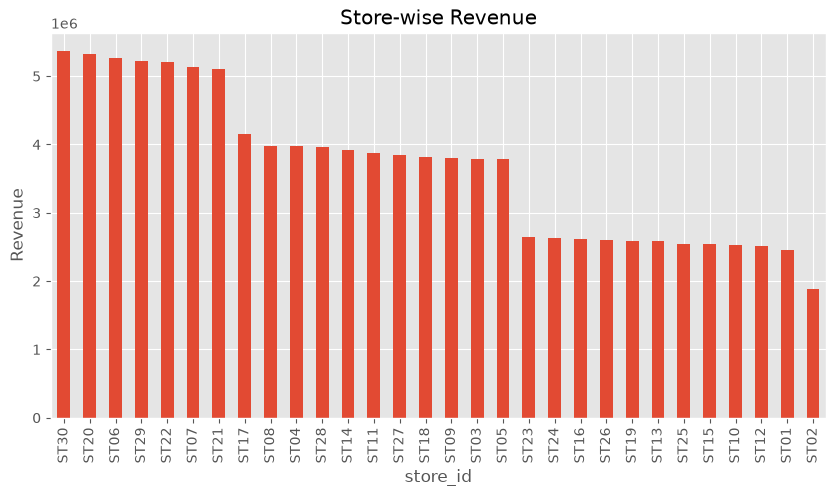

In [8]:
top_store = (
    sales.groupby("store_id")["total_value"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
top_store.plot(kind="bar")
plt.title("Store-wise Revenue")
plt.ylabel("Revenue")
plt.show()

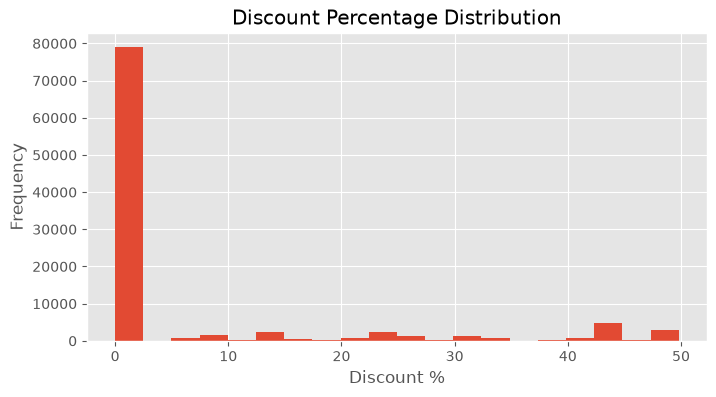

In [9]:
plt.figure(figsize=(8,4))
plt.hist(sales["discount_pct"], bins=20)

plt.title("Discount Percentage Distribution")
plt.xlabel("Discount %")
plt.ylabel("Frequency")
plt.show()

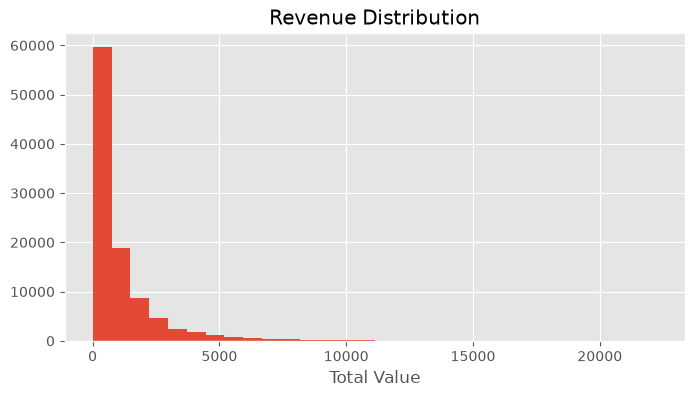

In [10]:
plt.figure(figsize=(8,4))
plt.hist(sales["total_value"], bins=30)

plt.title("Revenue Distribution")
plt.xlabel("Total Value")
plt.show()

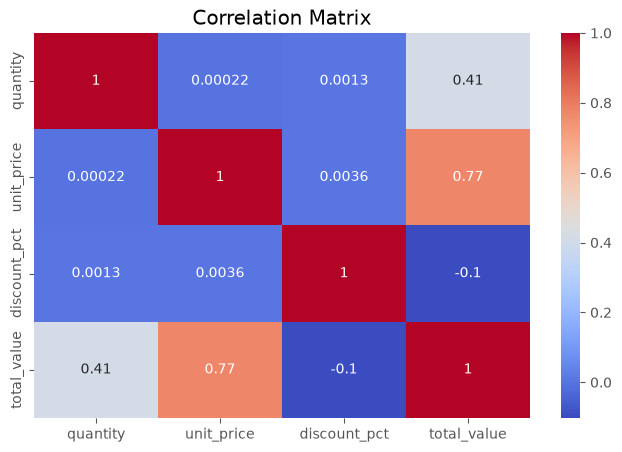

In [11]:
import seaborn as sns

numeric = sales[["quantity", "unit_price", "discount_pct", "total_value"]]

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [12]:
inventory.describe()

,stock_on_hand,reorder_point,safety_stock,last_restock_date
count,21228.000000,21228.000000,21228.000000,21228
mean,154.978566,59.906774,20.920859,2025-09-16 23:56:20.214810
min,0.000000,20.000000,4.000000,2025-05-06 00:00:00
25%,40.000000,39.000000,13.000000,2025-07-14 00:00:00
50%,125.000000,60.000000,20.000000,2025-09-12 00:00:00
75%,240.000000,80.000000,27.000000,2025-11-27 00:00:00
max,600.000000,100.000000,50.000000,2025-12-31 00:00:00
std,135.183820,23.376075,9.875016,NaN


In [13]:
low_stock = inventory[
    inventory["stock_on_hand"] <= inventory["reorder_point"]
]

print("Low Stock Items :", len(low_stock))

low_stock.head()

Low Stock Items : 5862


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
12,ST01,SKU00500,0,54,24,2025-08-25
16,ST16,SKU01037,0,92,38,2025-09-03
17,ST21,SKU01152,0,76,32,2025-10-02
22,ST08,SKU02381,0,36,15,2025-09-05
36,ST01,SKU03546,0,42,18,2025-09-25


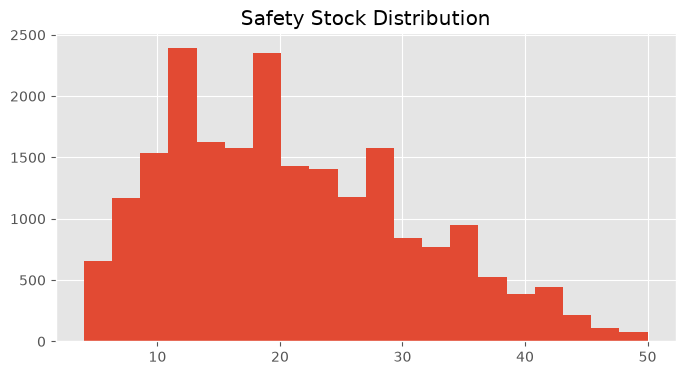

In [14]:
plt.figure(figsize=(8,4))

plt.hist(inventory["safety_stock"], bins=20)

plt.title("Safety Stock Distribution")

plt.show()

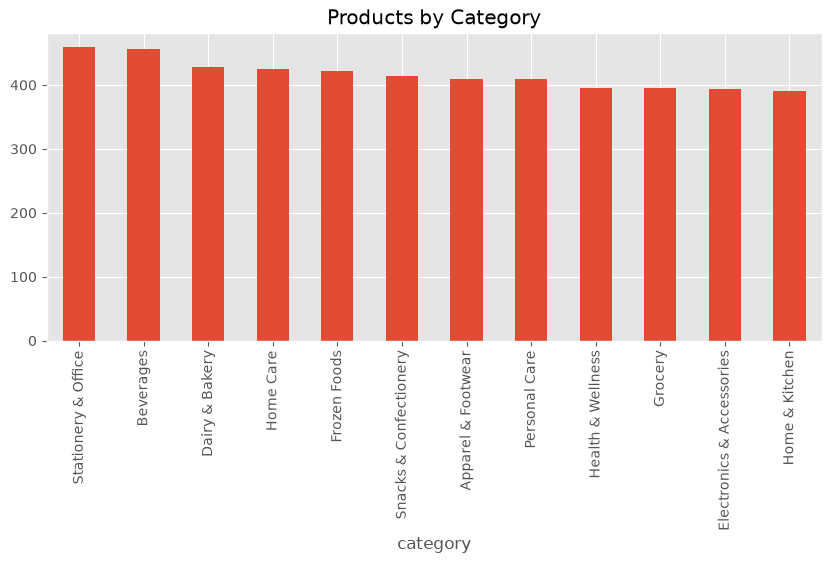

In [15]:
sku["category"].value_counts().plot(
    kind="bar",
    figsize=(10,4)
)

plt.title("Products by Category")

plt.show()

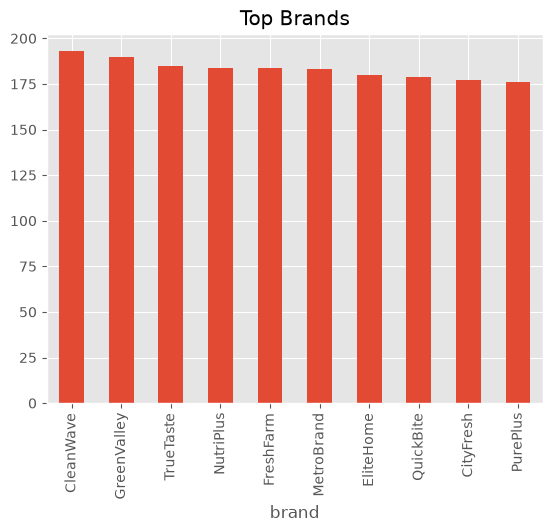

In [16]:
sku["brand"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top Brands")

plt.show()

## Business Insights

- Sales trend has been analyzed over time.
- Revenue contribution by each sales channel has been evaluated.
- Top-selling products and top-performing stores have been identified.
- Discount distribution has been examined.
- Low-stock products requiring replenishment have been identified.
- Product categories and brand distribution have been analyzed.

The datasets are now ready for Feature Engineering and Demand Forecasting.